## Load Data Files

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better viewing of DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
import glob
import os

# ===== LOAD BENCHMARK DATA =====
BENCHMARK_DIR = '/content/benchmark_logs'  # Directory containing benchmark CSVs
benchmark_csv_files = glob.glob(os.path.join(BENCHMARK_DIR, "*.csv"))

bench_data = {}
bench_throughput = {}
bench_ttft_data = {}
bench_ttft = {}
bench_mean_itl_data = {}
bench_mean_itl = {}
bench_median_itl_data = {}
bench_median_itl = {}


for file in benchmark_csv_files:
    df = pd.read_csv(file)

    # Ensure required columns exist
    required_cols = ['throughput', 'ttft', 'mean_itl', 'median_itl']
    if not all(col in df.columns for col in required_cols):
        print(f"⚠️ One or more required columns ({', '.join(required_cols)}) not found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0] # e.g., alpaca_benchmark_results_g2l
    # Normalize run_name for plotting (e.g., 'g2l' from 'alpaca_benchmark_results_g2l')
    # Assuming the format is 'prefix_gXX.csv'
    parts = run_name.split('_')
    if len(parts) >= 2 and parts[-1].startswith('g'):
        clean_run_name = parts[-1] # e.g., g2l
    else:
        clean_run_name = run_name # Fallback if naming convention changes

    # Store values and calculate average for each metric
    bench_data[clean_run_name] = df['throughput'].tolist()
    bench_throughput[clean_run_name] = df['throughput'].mean()

    bench_ttft_data[clean_run_name] = df['ttft'].tolist()
    bench_ttft[clean_run_name] = df['ttft'].mean()

    bench_mean_itl_data[clean_run_name] = df['mean_itl'].tolist()
    bench_mean_itl[clean_run_name] = df['mean_itl'].mean()

    bench_median_itl_data[clean_run_name] = df['median_itl'].tolist()
    bench_median_itl[clean_run_name] = df['median_itl'].mean()


print("Loaded benchmark data:")
for run, avg_tput in bench_throughput.items():
    print(f"  {run}: Average Throughput = {avg_tput:.2f}")
    print(f"  {run}: Average TTFT = {bench_ttft[run]:.2f}")
    print(f"  {run}: Average Mean ITL = {bench_mean_itl[run]:.2f}")
    print(f"  {run}: Average Median ITL = {bench_median_itl[run]:.2f}")

Loaded benchmark data:
  g3m: Average Throughput = 58.16
  g3m: Average TTFT = 0.07
  g3m: Average Mean ITL = 0.02
  g3m: Average Median ITL = 0.02
  g2l: Average Throughput = 45.65
  g2l: Average TTFT = 0.08
  g2l: Average Mean ITL = 0.02
  g2l: Average Median ITL = 0.02
  g2m: Average Throughput = 48.19
  g2m: Average TTFT = 0.08
  g2m: Average Mean ITL = 0.02
  g2m: Average Median ITL = 0.02
  g3l: Average Throughput = 61.86
  g3l: Average TTFT = 0.07
  g3l: Average Mean ITL = 0.02
  g3l: Average Median ITL = 0.02


In [ ]:
log_files = {
    'g2l': '/content/server_logs/server_benchmark_g2l_8.log',
    'g2m': '/content/server_logs/server_benchmark_g2m_8.log',
    'g3l': '/content/server_logs/server_benchmark_g3l_8.log',
    'g3m': '/content/server_logs/server_benchmark_g3m_8.log',
}

for var_name, file_path in log_files.items():
    try:
        with open(file_path, 'r') as f:
            globals()[var_name] = f.read()
        print(f'Successfully loaded {file_path} into variable {var_name}')
    except FileNotFoundError:
        print(f'Error: {file_path} not found. Please ensure the file is in the correct path.')
    except Exception as e:
        print(f'An error occurred while loading {file_path}: {e}')


Error: /content/server_logs/server_benchmark_g2l_8.log not found. Please ensure the file is in the correct path.
Error: /content/server_logs/server_benchmark_g2m_8.log not found. Please ensure the file is in the correct path.
Error: /content/server_logs/server_benchmark_g3l_8.log not found. Please ensure the file is in the correct path.
Error: /content/server_logs/server_benchmark_g3m_8.log not found. Please ensure the file is in the correct path.


### 1. Power Logs: `power_log_g2l.csv`

In [ ]:
try:
    power_df = pd.read_csv('/content/power_logs/power_log_g2l.csv')
    print('Successfully loaded power_log_g2l.csv')
    display(power_df.head())
except FileNotFoundError:
    print('Error: power_log_g2l.csv not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading power_log_g2l.csv: {e}')

Successfully loaded power_log_g2l.csv


,timestamp,power.draw [W]
0,Mon Mar 23 19:55:35 IST 2026,91 W
1,Mon Mar 23 19:55:35 IST 2026,118 W
2,Mon Mar 23 19:55:35 IST 2026,90 W
3,Mon Mar 23 19:55:35 IST 2026,101 W
4,Mon Mar 23 19:55:35 IST 2026,91 W


### 2. Benchmark Results: `alpaca_benchmark_results_g2l.csv`

In [ ]:
try:
    benchmark_df = pd.read_csv('/content/benchmark_logs/alpaca_benchmark_results_g2l.csv')
    print('Successfully loaded alpaca_benchmark_results_g2l.csv')
    display(benchmark_df.head())
except FileNotFoundError:
    print('Error: alpaca_benchmark_results_g2l.csv not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading alpaca_benchmark_results_g2l.csv: {e}')

Error: alpaca_benchmark_results_g2l.csv not found. Please ensure the file is in the correct path.


In [ ]:
import glob
import os

# ===== LOAD BENCHMARK DATA =====
BENCHMARK_DIR = '/content/benchmark_logs'  # Directory containing benchmark CSVs
benchmark_csv_files = glob.glob(os.path.join(BENCHMARK_DIR, "*.csv"))

bench_data = {}
bench_throughput = {}
bench_ttft_data = {}
bench_ttft = {}
bench_mean_itl_data = {}
bench_mean_itl = {}
bench_median_itl_data = {}
bench_median_itl = {}


for file in benchmark_csv_files:
    df = pd.read_csv(file)

    # Ensure required columns exist
    required_cols = ['throughput', 'ttft', 'mean_itl', 'median_itl']
    if not all(col in df.columns for col in required_cols):
        print(f"⚠️ One or more required columns ({', '.join(required_cols)}) not found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0] # e.g., alpaca_benchmark_results_g2l
    # Normalize run_name for plotting (e.g., 'g2l' from 'alpaca_benchmark_results_g2l')
    # Assuming the format is 'prefix_gXX.csv'
    parts = run_name.split('_')
    if len(parts) >= 2 and parts[-1].startswith('g'):
        clean_run_name = parts[-1] # e.g., g2l
    else:
        clean_run_name = run_name # Fallback if naming convention changes

    # Store values and calculate average for each metric
    bench_data[clean_run_name] = df['throughput'].tolist()
    bench_throughput[clean_run_name] = df['throughput'].mean()

    bench_ttft_data[clean_run_name] = df['ttft'].tolist()
    bench_ttft[clean_run_name] = df['ttft'].mean()

    bench_mean_itl_data[clean_run_name] = df['mean_itl'].tolist()
    bench_mean_itl[clean_run_name] = df['mean_itl'].mean()

    bench_median_itl_data[clean_run_name] = df['median_itl'].tolist()
    bench_median_itl[clean_run_name] = df['median_itl'].mean()


print("Loaded benchmark data:")
for run, avg_tput in bench_throughput.items():
    print(f"  {run}: Average Throughput = {avg_tput:.2f}")
    print(f"  {run}: Average TTFT = {bench_ttft[run]:.2f}")
    print(f"  {run}: Average Mean ITL = {bench_mean_itl[run]:.2f}")
    print(f"  {run}: Average Median ITL = {bench_median_itl[run]:.2f}")

Loaded benchmark data:
  g3m: Average Throughput = 58.16
  g3m: Average TTFT = 0.07
  g3m: Average Mean ITL = 0.02
  g3m: Average Median ITL = 0.02
  g2l: Average Throughput = 45.65
  g2l: Average TTFT = 0.08
  g2l: Average Mean ITL = 0.02
  g2l: Average Median ITL = 0.02
  g2m: Average Throughput = 48.19
  g2m: Average TTFT = 0.08
  g2m: Average Mean ITL = 0.02
  g2m: Average Median ITL = 0.02
  g3l: Average Throughput = 61.86
  g3l: Average TTFT = 0.07
  g3l: Average Mean ITL = 0.02
  g3l: Average Median ITL = 0.02


### 3. Server Logs: `server_benchmark_g2l_16.log`

In [ ]:
try:
    with open('/content/server_logs/server_benchmark_g2l_16.log', 'r') as f:
        server_log_content = f.readlines()
    print('Successfully loaded server_benchmark_g2l_16.log')
    print('First 10 lines of the log file:')
    for i, line in enumerate(server_log_content[:10]):
        print(line.strip())
except FileNotFoundError:
    print('Error: server_benchmark_g2l_16.log not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading server_benchmark_g2l_16.log: {e}')

Error: server_benchmark_g2l_16.log not found. Please ensure the file is in the correct path.


In [ ]:
log_files = {
    'g2l': '/content/server_logs/server_benchmark_g2l.log',
    'g2m': '/content/server_logs/server_benchmark_g2m.log',
    'g3l': '/content/server_logs/server_benchmark_g3l.log',
    'g3m': '/content/server_logs/server_benchmark_g3m.log',
}

for var_name, file_path in log_files.items():
    try:
        with open(file_path, 'r') as f:
            globals()[var_name] = f.read()
        print(f'Successfully loaded {file_path} into variable {var_name}')
    except FileNotFoundError:
        print(f'Error: {file_path} not found. Please ensure the file is in the correct path.')
    except Exception as e:
        print(f'An error occurred while loading {file_path}: {e}')


Successfully loaded /content/server_logs/server_benchmark_g2l.log into variable g2l
Successfully loaded /content/server_logs/server_benchmark_g2m.log into variable g2m
Successfully loaded /content/server_logs/server_benchmark_g3l.log into variable g3l
Successfully loaded /content/server_logs/server_benchmark_g3m.log into variable g3m


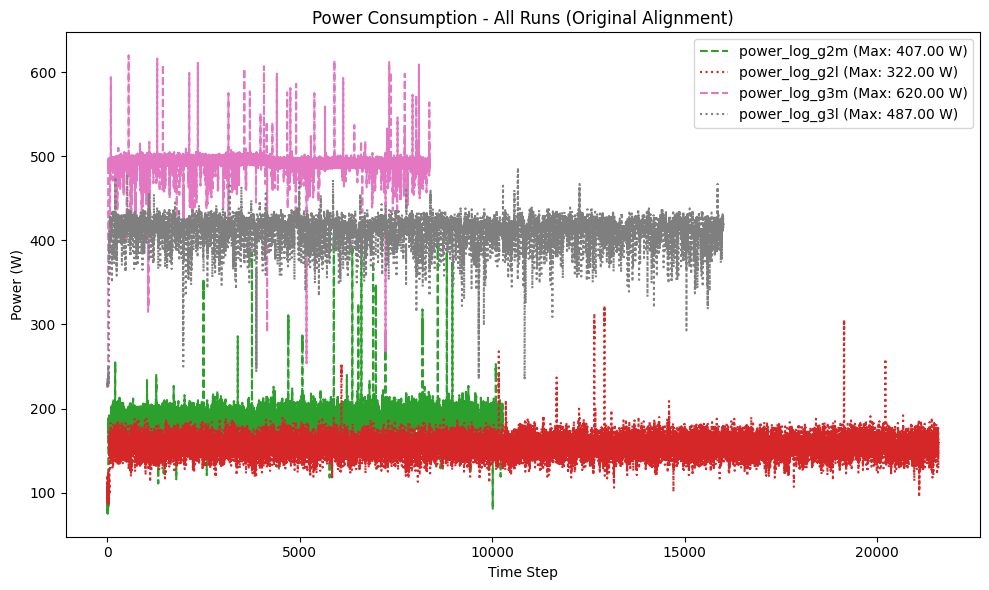

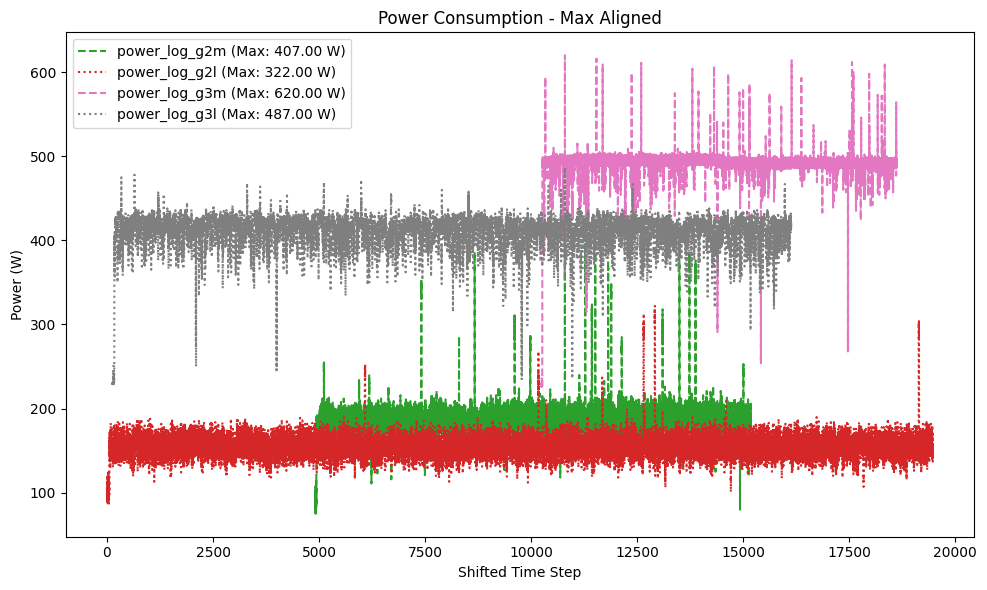

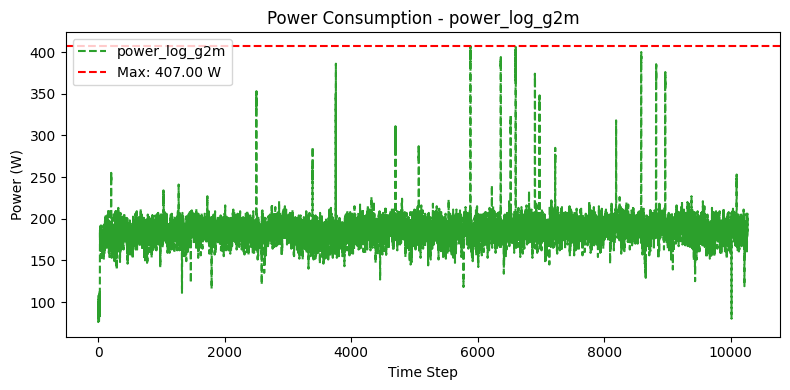

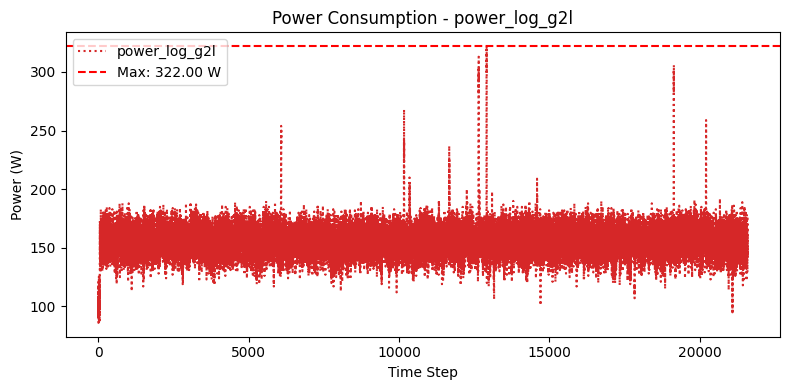

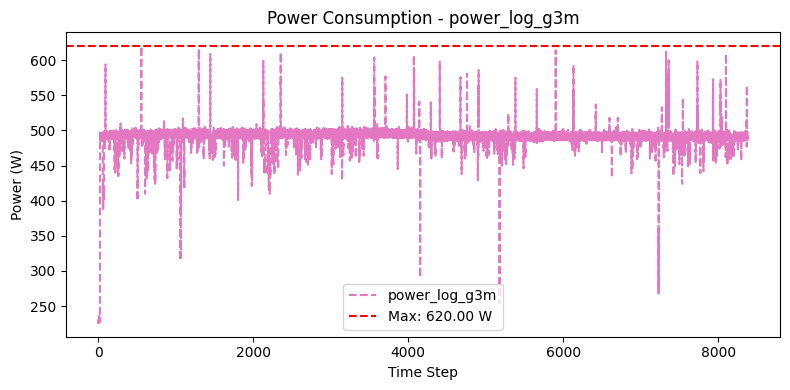

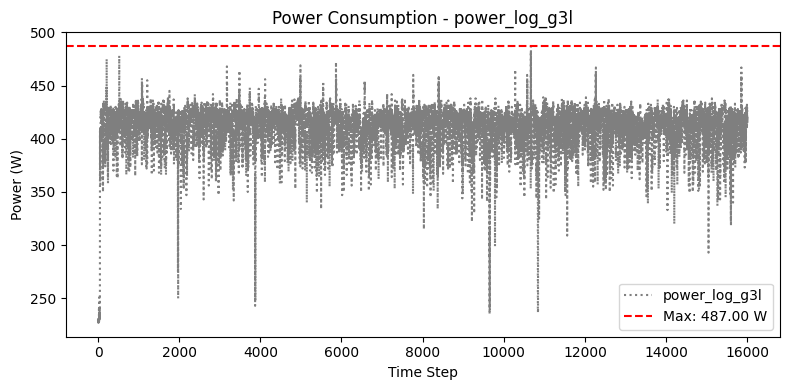


=== Max Power Consumption ===
power_log_g2m: 407.00 W
power_log_g2l: 322.00 W
power_log_g3m: 620.00 W
power_log_g3l: 487.00 W


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# ===== SETTINGS =====
DATA_DIR = "./power_logs"  # Change to your folder path

# Distinct colors for each config
color_map = {
    "2": "#1f77b4",    # blue
    "2s": "#ff7f0e",   # orange
    "2m": "#2ca02c",   # green
    "2l": "#d62728",   # red
    "3": "#9467bd",    # purple
    "3s": "#8c564b",   # brown
    "3m": "#e377c2",   # pink
    "3l": "#7f7f7f",   # gray
}

# Line styles
style_map = {"": "-.", "s": "-", "m": "--", "l": ":"}

# Order for plotting
plot_order = ["2", "2s", "2m", "2l", "3", "3s", "3m", "3l"]

# ===== LOAD DATA =====
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_dict = {}
max_values = {}
meta_info = {}

for file in csv_files:
    df = pd.read_csv(file)

    # Find power column
    power_col = None
    for col in df.columns:
        if "power" in col.lower():
            power_col = col
            break
    if power_col is None:
        print(f"⚠️ No power column found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0]  # e.g., power_logs_g2s

    # Parse version & config
    parts = run_name.split("_")
    if len(parts) >= 2:
        version_config = parts[-1]  # e.g., 'g2', 'g2s', 'g3m'
        if version_config.startswith("g"):
            norm_cfg = version_config[1:]  # strip 'g' → '2', '2s', '3m', etc.
        else:
            norm_cfg = version_config
        gaudi_version = norm_cfg[0]  # '2' or '3'
        cfg_suffix = norm_cfg[1:]    # '', 's', 'm', 'l'
        meta_info[run_name] = (gaudi_version, cfg_suffix, norm_cfg)
    else:
        meta_info[run_name] = ("?", "?", "?")
        norm_cfg = "?"

    # Clean values
    power_values = (
        df[power_col]
        .astype(str)
        .str.strip()
        .str.replace("W", "", regex=False)
        .str.replace("w", "", regex=False)
        .astype(float)
        .dropna()
        .to_numpy()
    )

    data_dict[run_name] = power_values
    max_values[run_name] = np.max(power_values)

# ===== ALIGN FOR MAX =====
max_aligned_data = {}
max_length = max(len(v) for v in data_dict.values())

for run, values in data_dict.items():
    max_idx = np.argmax(values)
    shift = (max_length // 2) - max_idx
    aligned = np.full(max_length, np.nan)
    start = max(0, shift)
    end = min(max_length, shift + len(values))
    aligned[start:end] = values[:end - start]
    max_aligned_data[run] = aligned

# ===== SORT =====
sorted_runs = sorted(
    data_dict.keys(),
    key=lambda x: plot_order.index(meta_info[x][2]) if meta_info[x][2] in plot_order else 999
)

# ===== PLOT: ORIGINAL =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config like '2', '2s', etc.
    plt.plot(
        data_dict[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - All Runs (Original Alignment)")
plt.xlabel("Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== PLOT: MAX ALIGNED =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.plot(
        max_aligned_data[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - Max Aligned")
plt.xlabel("Shifted Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL PLOTS =====
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.figure(figsize=(8, 4))
    plt.plot(
        data_dict[run],
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-"),
        label=run
    )
    plt.axhline(max_values[run], color='red', linestyle='--',
                label=f"Max: {max_values[run]:.2f} W")
    plt.title(f"Power Consumption - {run}")
    plt.xlabel("Time Step")
    plt.ylabel("Power (W)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")



=== Max Power Consumption ===
power_log_g2m: 407.00 W
power_log_g2l: 322.00 W
power_log_g3m: 620.00 W
power_log_g3l: 487.00 W


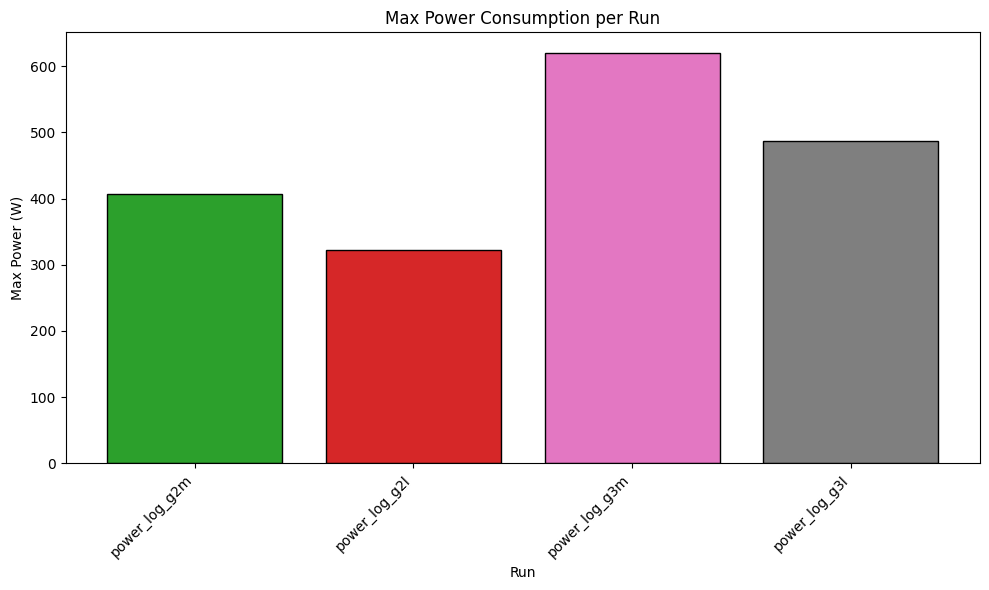

In [ ]:
# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")

# ===== HISTOGRAM OF MAX VALUES =====
plt.figure(figsize=(10, 6))
bars = []
labels = []
colors = []

for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config
    bars.append(max_values[run])
    labels.append(run)
    colors.append(color_map.get(cfg_key, "black"))

plt.bar(labels, bars, color=colors, edgecolor="black")
plt.title("Max Power Consumption per Run")
plt.xlabel("Run")
plt.ylabel("Max Power (W)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
g2='''

'''

g2_l: Max Prompt Throughput = 6.4 tokens/s, Max Generation Throughput = 50.3 tokens/s
g2_m: Max Prompt Throughput = 8.0 tokens/s, Max Generation Throughput = 54.1 tokens/s
g3_l: Max Prompt Throughput = 6.4 tokens/s, Max Generation Throughput = 67.4 tokens/s
g3_m: Max Prompt Throughput = 5.6 tokens/s, Max Generation Throughput = 59.9 tokens/s


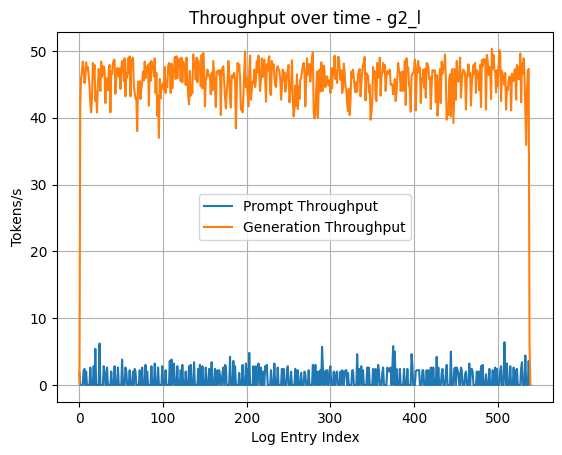

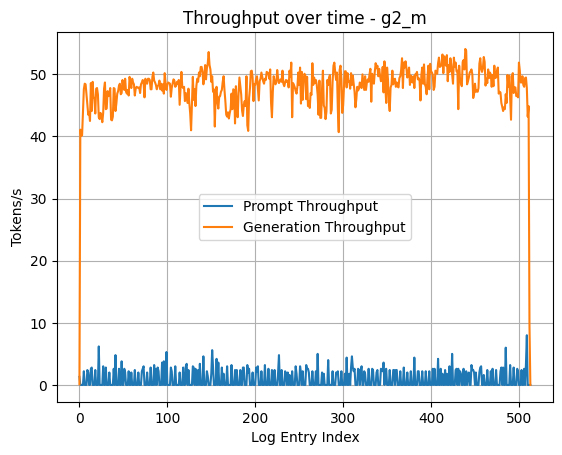

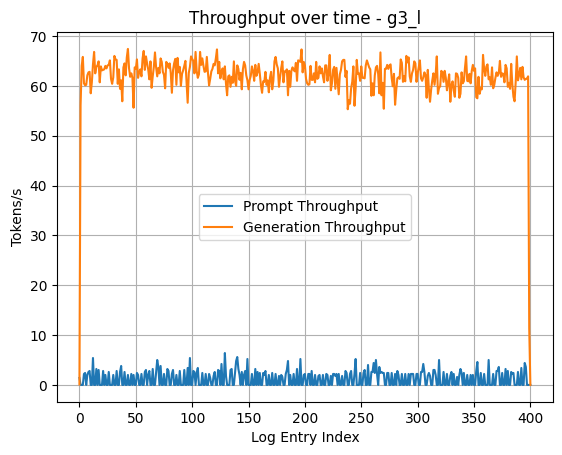

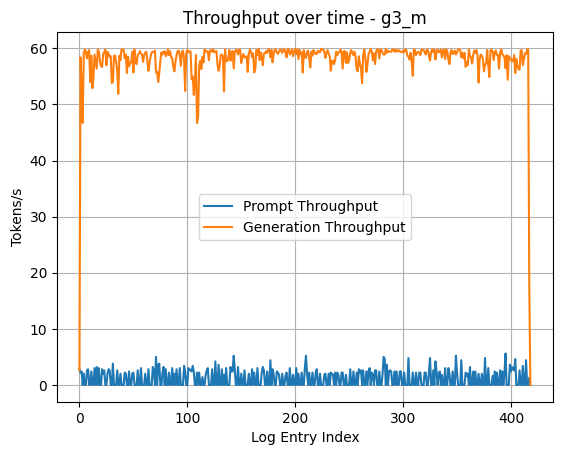

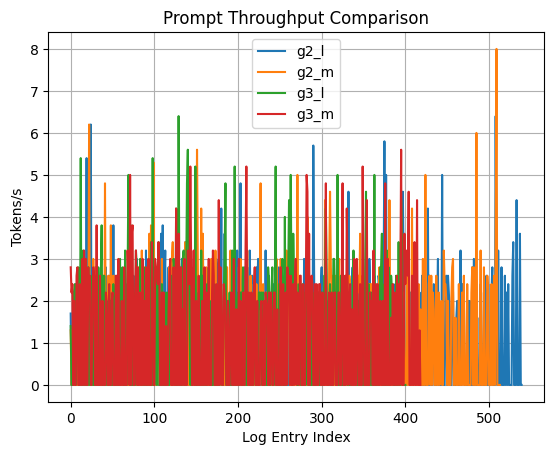

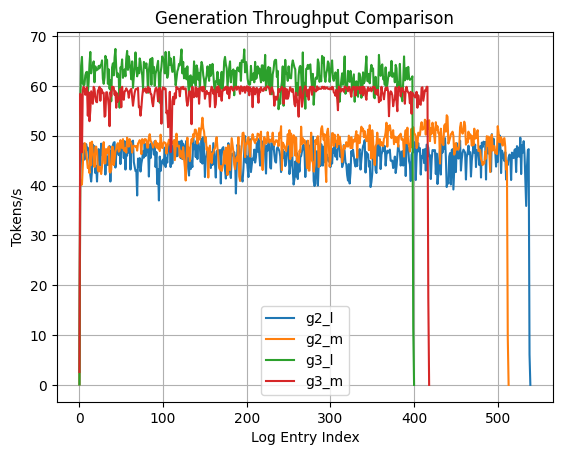

In [ ]:
import re
import matplotlib.pyplot as plt



# Store all in a dict for processing
log_data = {
    "g2_l": g2l,
    "g2_m": g2m, "g3_l": g3l,  "g3_m": g3m,
}

pattern = re.compile(
    r"Avg prompt throughput: ([\d\.]+) tokens/s, Avg generation throughput: ([\d\.]+) tokens/s"
)

results = {}

for name, text in log_data.items():
    prompt_vals = []
    gen_vals = []

    for match in pattern.finditer(text):
        prompt_vals.append(float(match.group(1)))
        gen_vals.append(float(match.group(2)))

    if prompt_vals and gen_vals:
        results[name] = {
            "prompt_vals": prompt_vals,
            "gen_vals": gen_vals,
            "max_prompt": max(prompt_vals),
            "max_gen": max(gen_vals),
        }

# Print max values
for name, vals in results.items():
    print(f"{name}: Max Prompt Throughput = {vals['max_prompt']} tokens/s, "
          f"Max Generation Throughput = {vals['max_gen']} tokens/s")

# --- Plot individual graphs ---
for name, vals in results.items():
    plt.figure()
    plt.plot(vals["prompt_vals"], label="Prompt Throughput")
    plt.plot(vals["gen_vals"], label="Generation Throughput")
    plt.title(f"Throughput over time - {name}")
    plt.xlabel("Log Entry Index")
    plt.ylabel("Tokens/s")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Comparative plots ---
# Prompt throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["prompt_vals"], label=name)
plt.title("Prompt Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()

# Generation throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["gen_vals"], label=name)
plt.title("Generation Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()


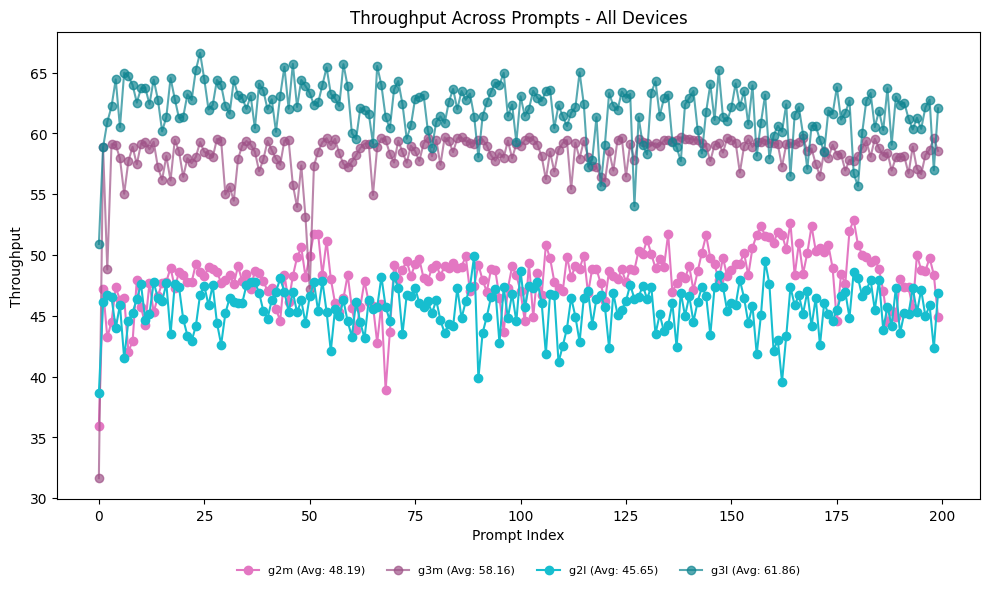

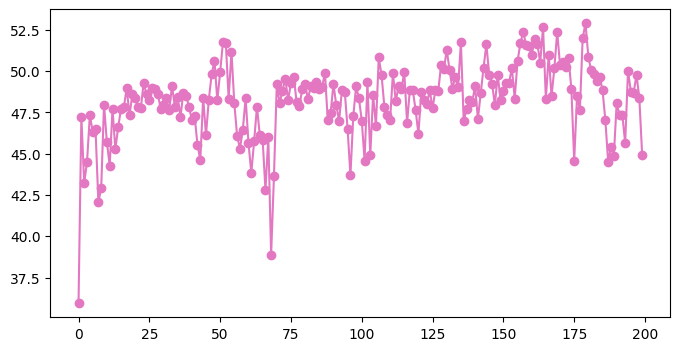

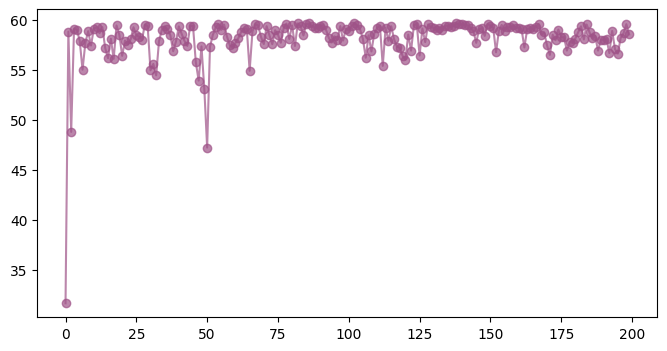

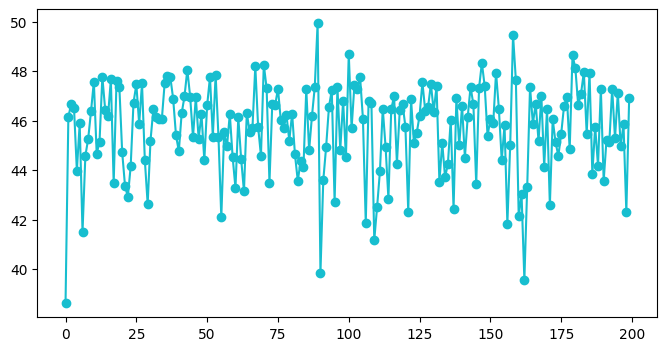

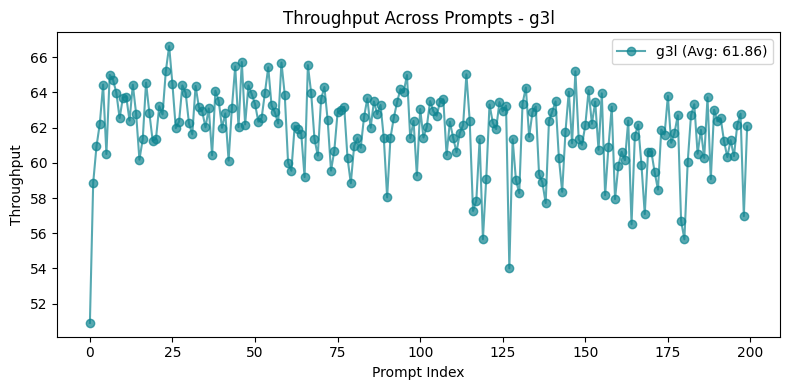

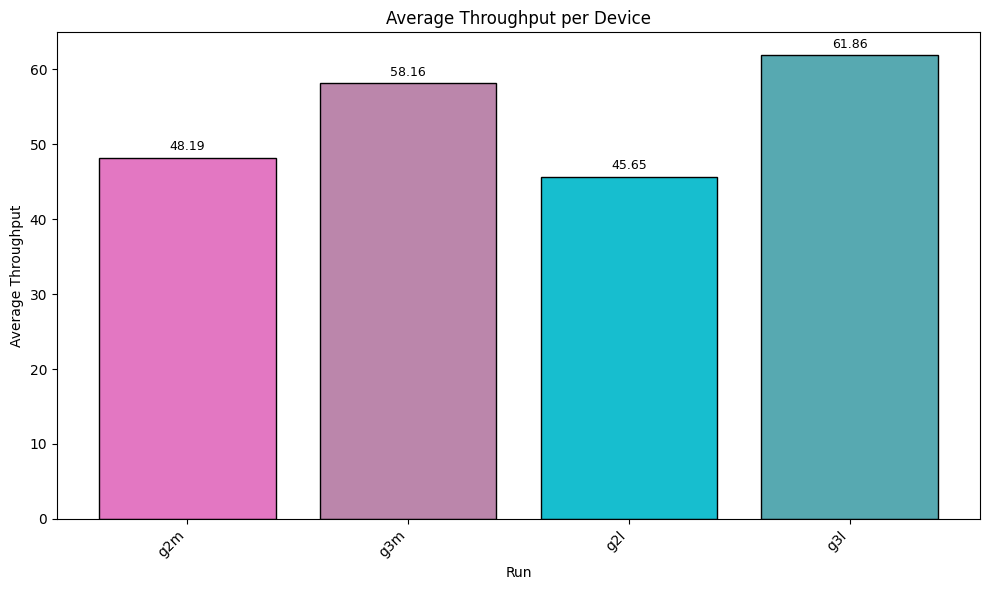

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

def plot_benchmark_metric(metric_name, data_dict, avg_dict):
    """
    Plots 'All Devices', 'Individual', and 'Average' charts for a given benchmark metric.
    """
    # ===== PLOT: ALL DEVICES METRIC =====
    plt.figure(figsize=(10, 6))
    for run in bench_sorted_runs:
        plt.plot(
            data_dict[run],
            marker='o',
            label=f"{run} (Avg: {avg_dict[run]:.2f})",
            color=bench_color_map[run],
            linestyle="-"
        )
    plt.title(f"{metric_name.replace('_', ' ').title()} Across Prompts - All Devices")
    plt.xlabel("Prompt Index")
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.legend(
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=4,
        frameon=False
    )
    plt.tight_layout()
    plt.show()

    # ===== INDIVIDUAL METRIC PLOTS =====
    for run in bench_sorted_runs:
        plt.figure(figsize=(8, 4))
        plt.plot(
            data_dict[run],
            marker='o',
            color=bench_color_map[run],
            linestyle="-",
            label=f"{run} (Avg: {avg_dict[run]:.2f})"
        )
    plt.title(f"{metric_name.replace('_', ' ').title()} Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ===== HISTOGRAM OF AVG METRIC =====
    plt.figure(figsize=(10, 6))
    bars = [avg_dict[run] for run in bench_sorted_runs]
    labels = [run for run in bench_sorted_runs]
    colors = [bench_color_map[run] for run in bench_sorted_runs]

    plt.bar(labels, bars, color=colors, edgecolor="black")
    for i, val in enumerate(bars):
        plt.text(i, val + 0.01 * max(bars), f"{val:.2f}", ha="center", va="bottom", fontsize=9)
    plt.title(f"Average {metric_name.replace('_', ' ').title()} per Device")
    plt.xlabel("Run")
    plt.ylabel(f"Average {metric_name.replace('_', ' ').title()}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Call the function for throughput
plot_benchmark_metric("Throughput", bench_data, bench_throughput)

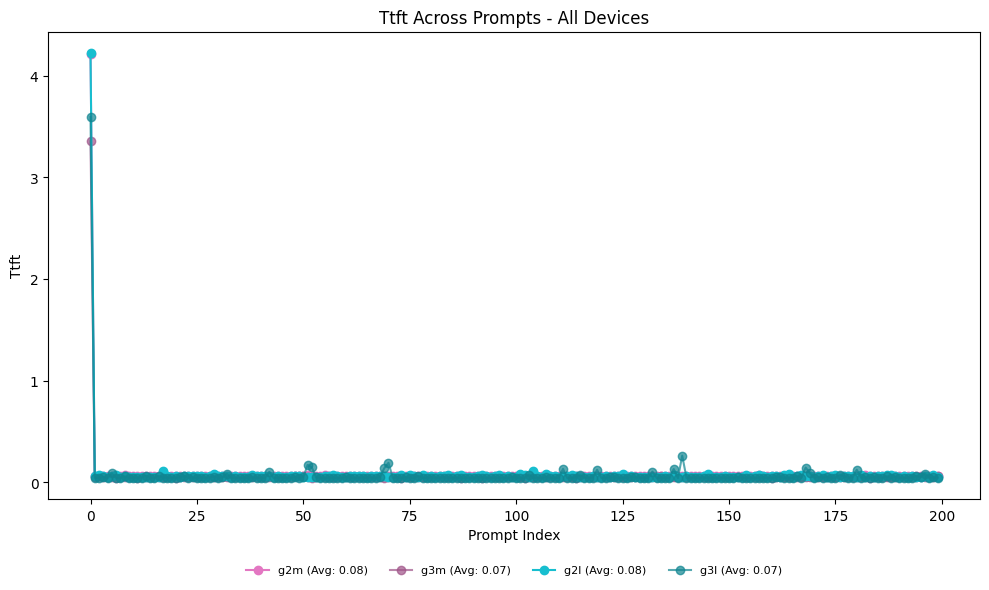

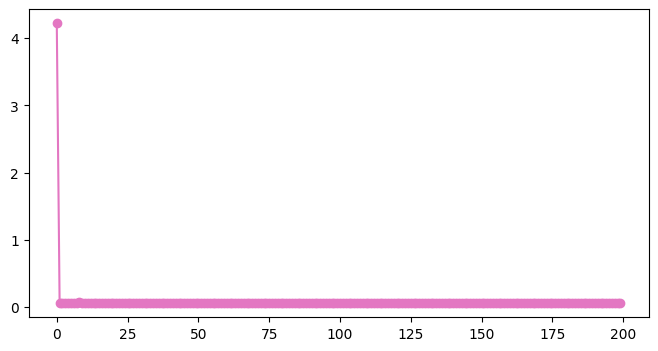

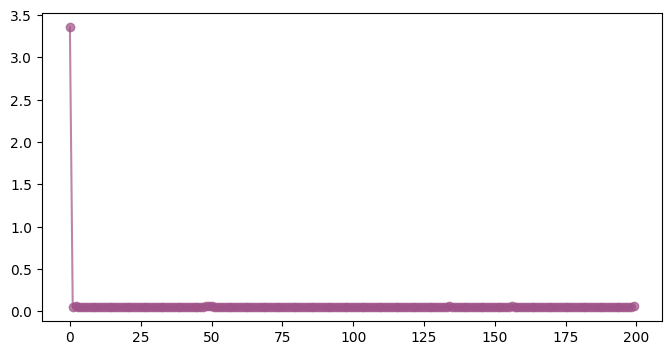

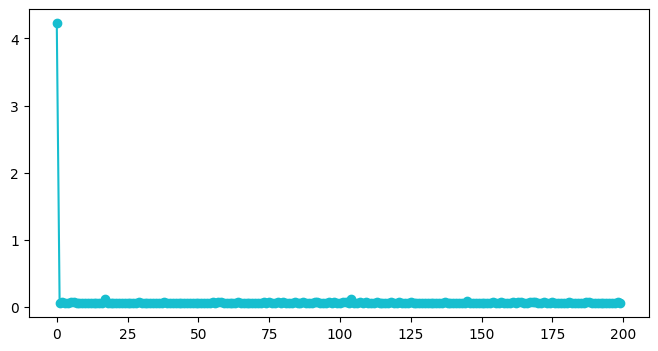

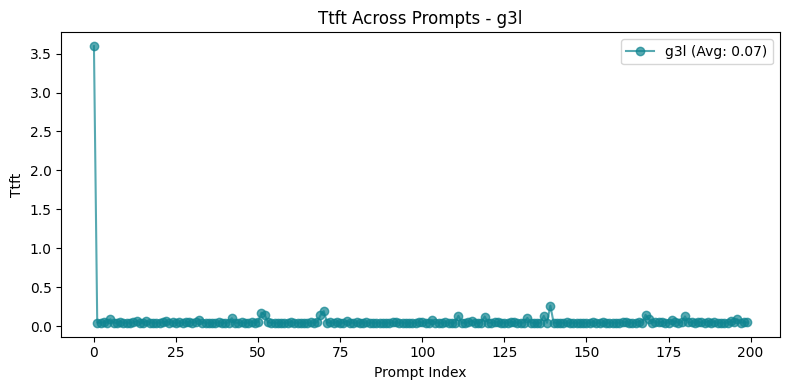

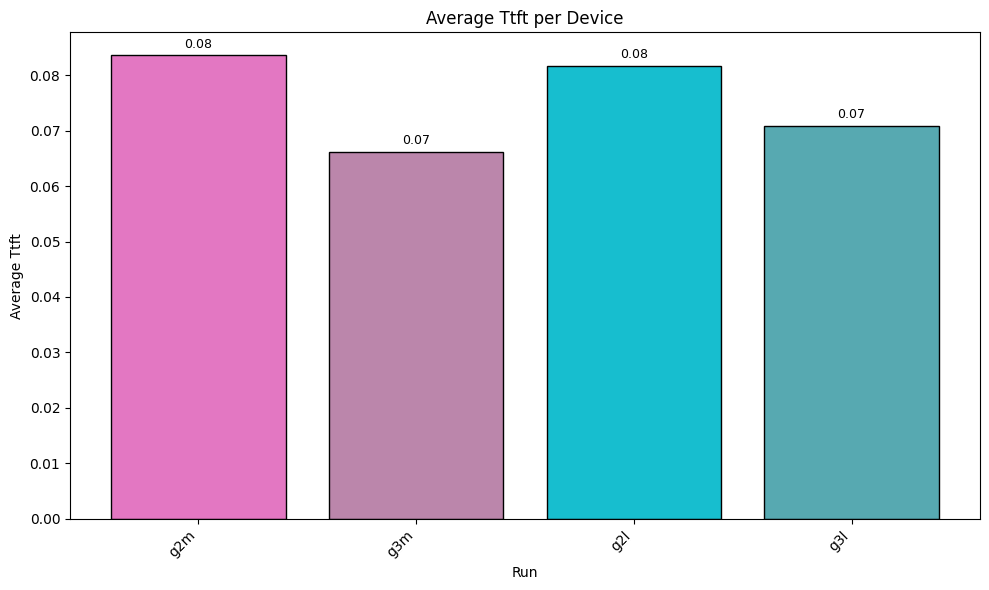

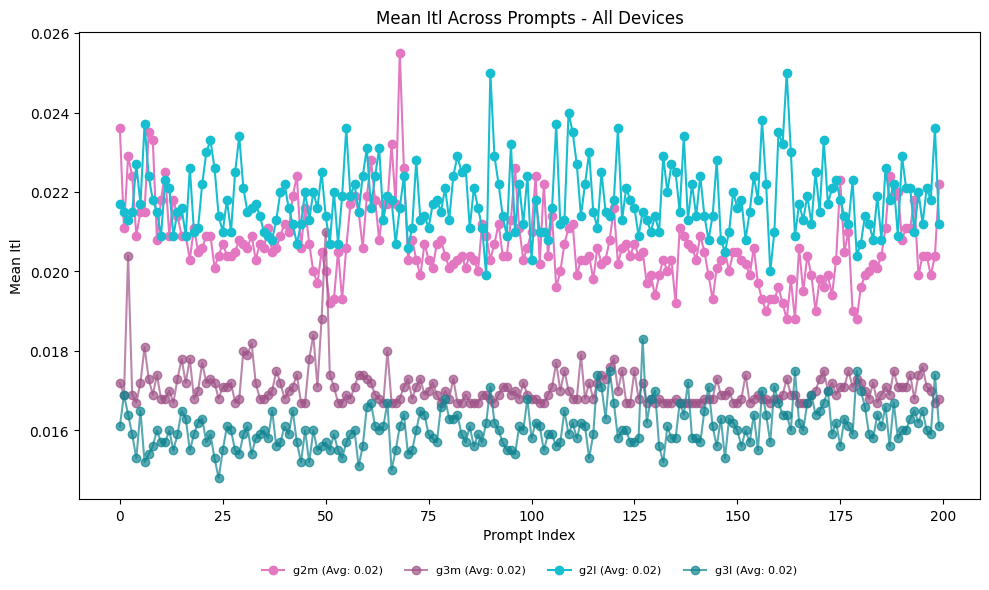

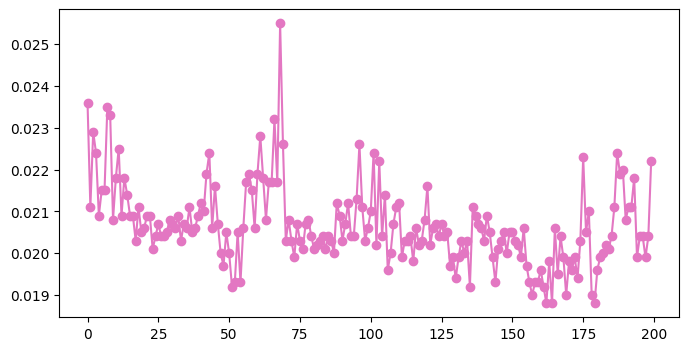

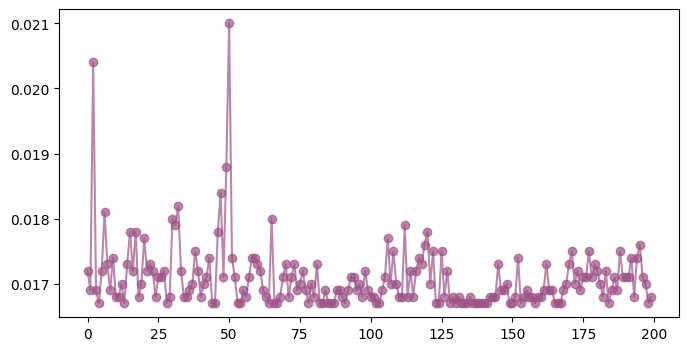

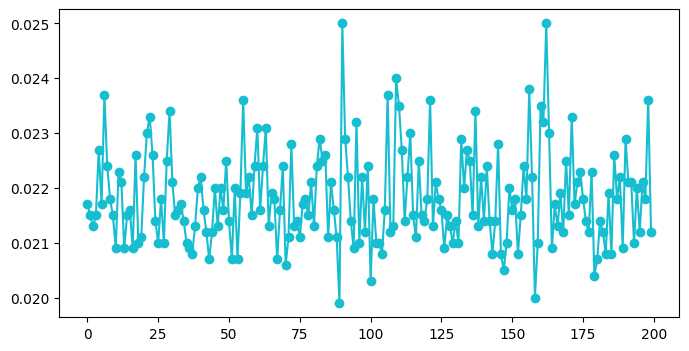

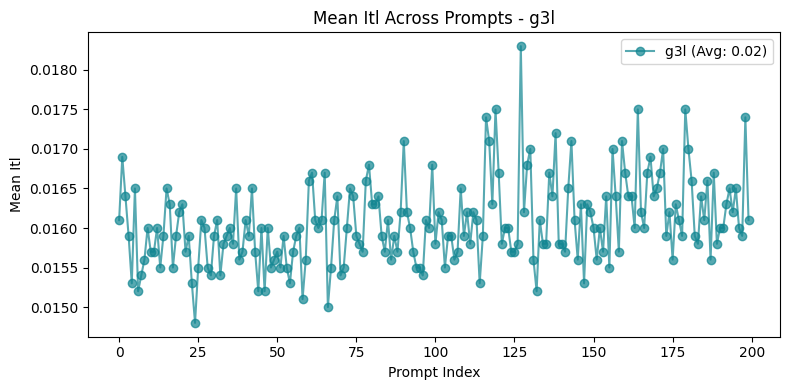

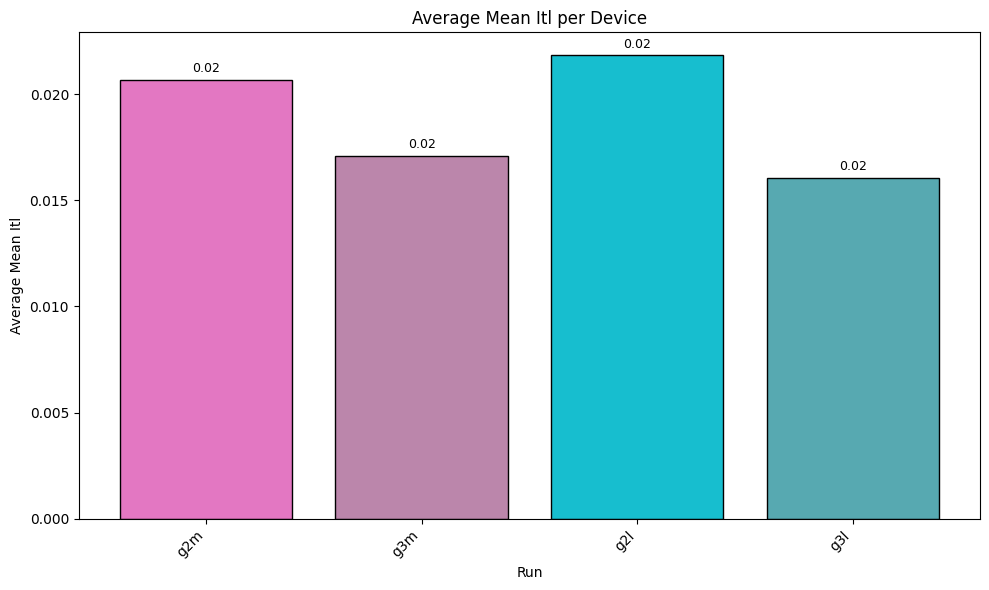

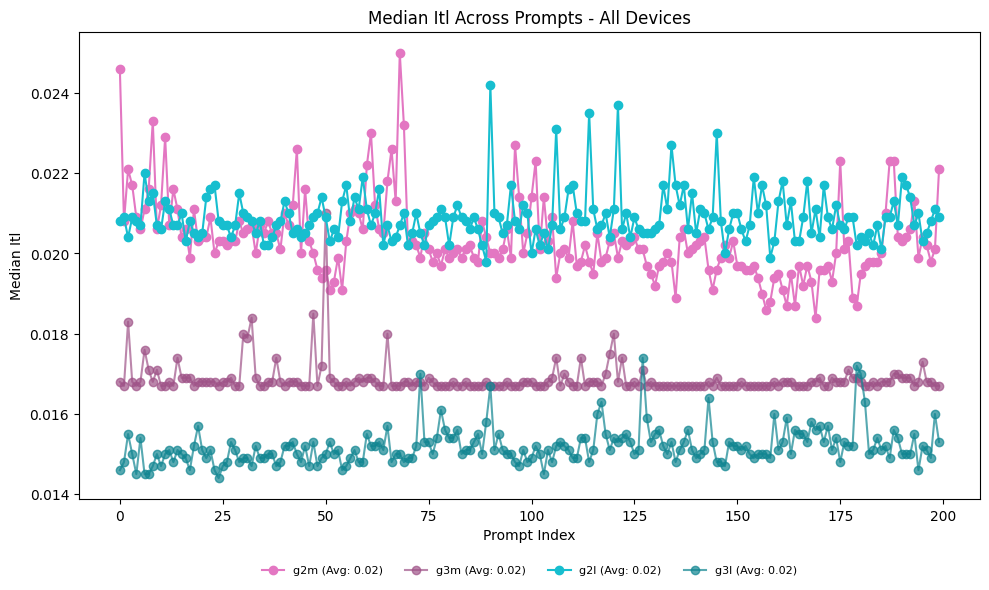

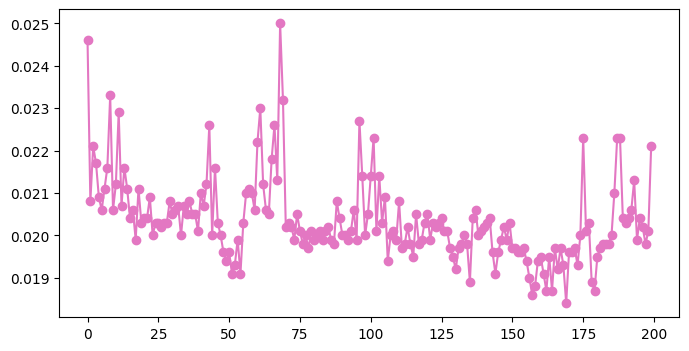

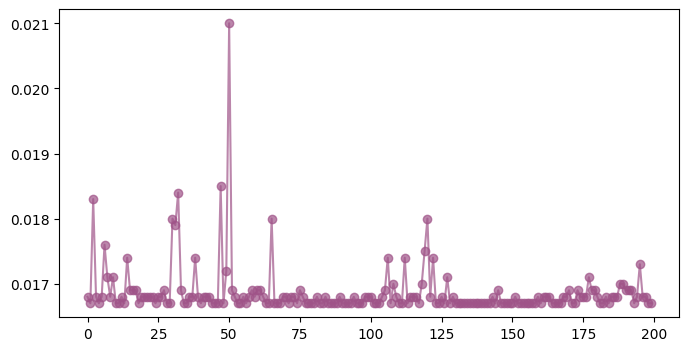

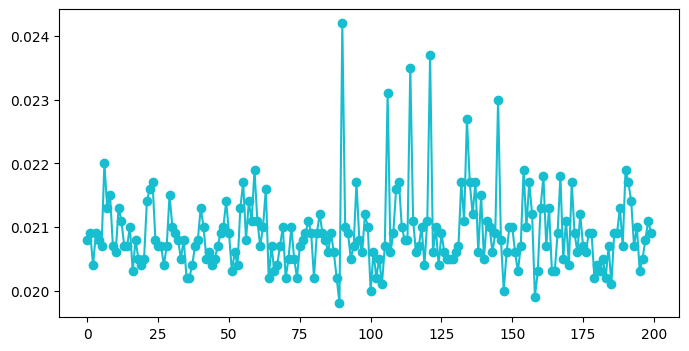

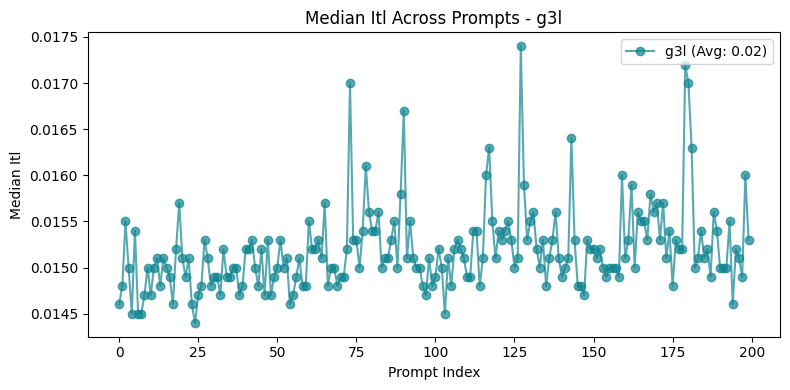

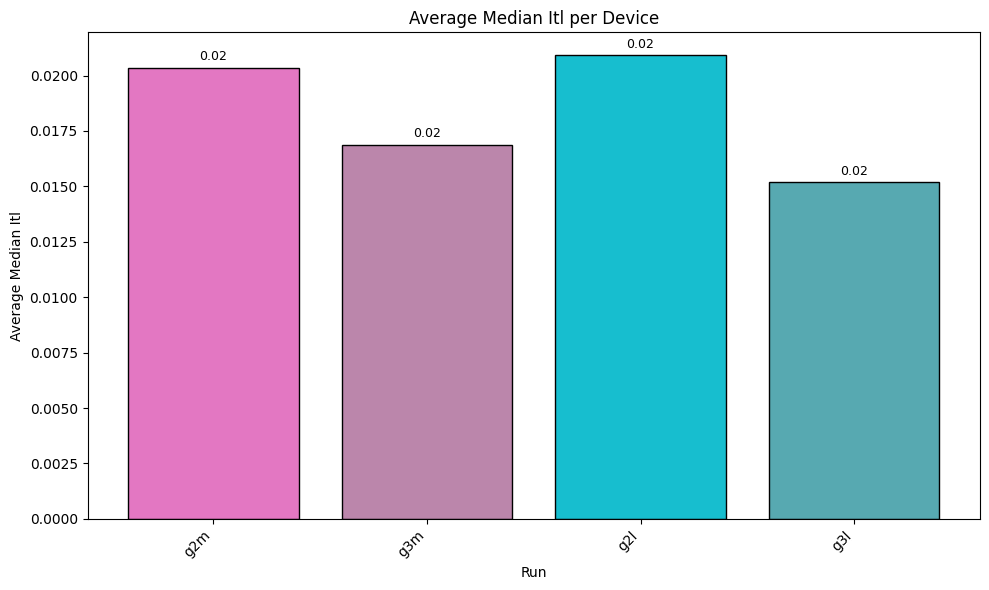

In [ ]:
# Call the function for TTFT
plot_benchmark_metric("TTFT", bench_ttft_data, bench_ttft)

# Call the function for Mean ITL
plot_benchmark_metric("Mean ITL", bench_mean_itl_data, bench_mean_itl)

# Call the function for Median ITL
plot_benchmark_metric("Median ITL", bench_median_itl_data, bench_median_itl)

In [ ]:
# Final requested code block


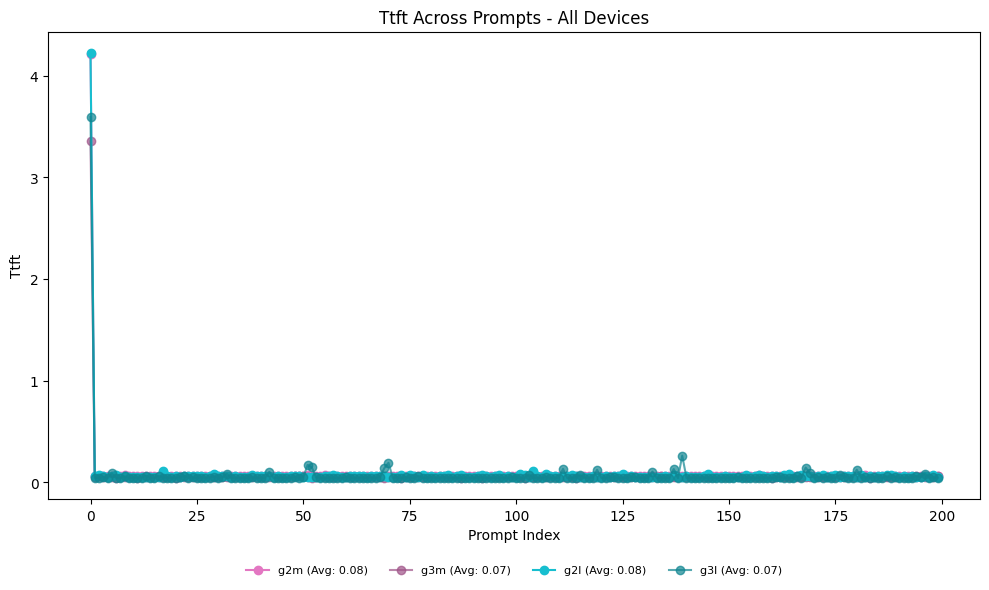

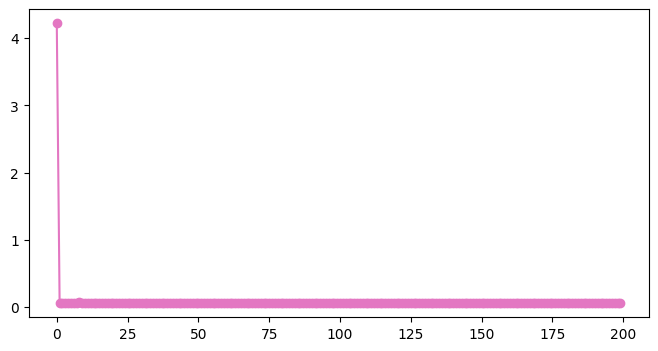

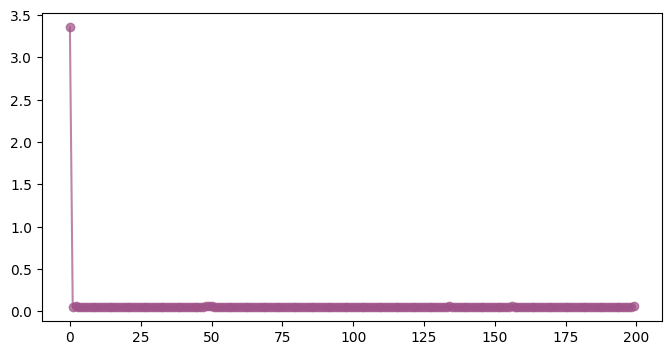

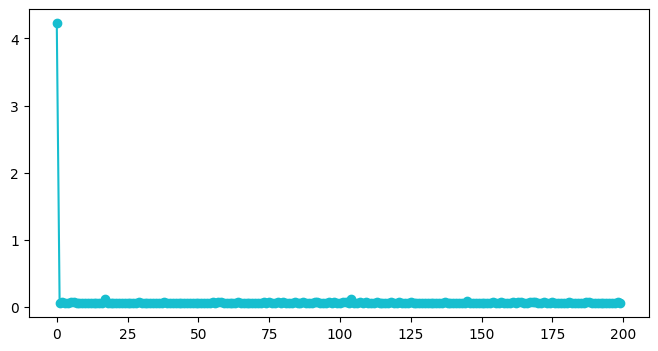

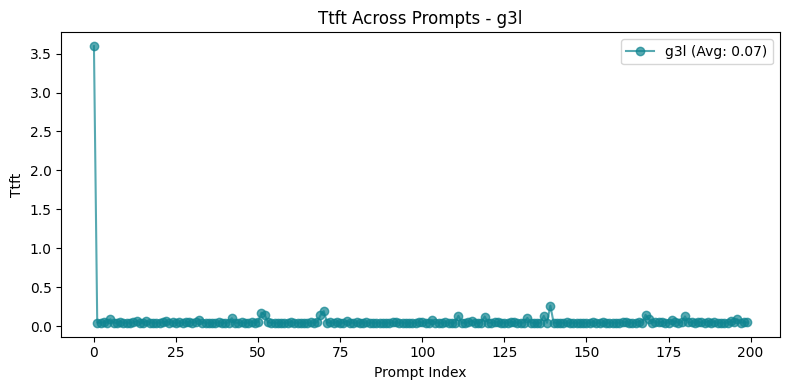

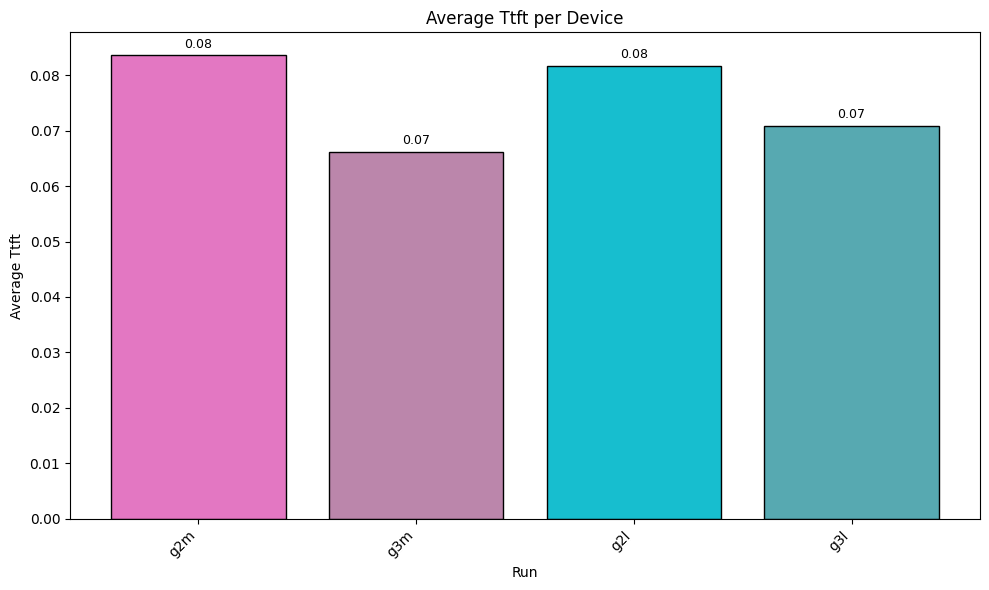

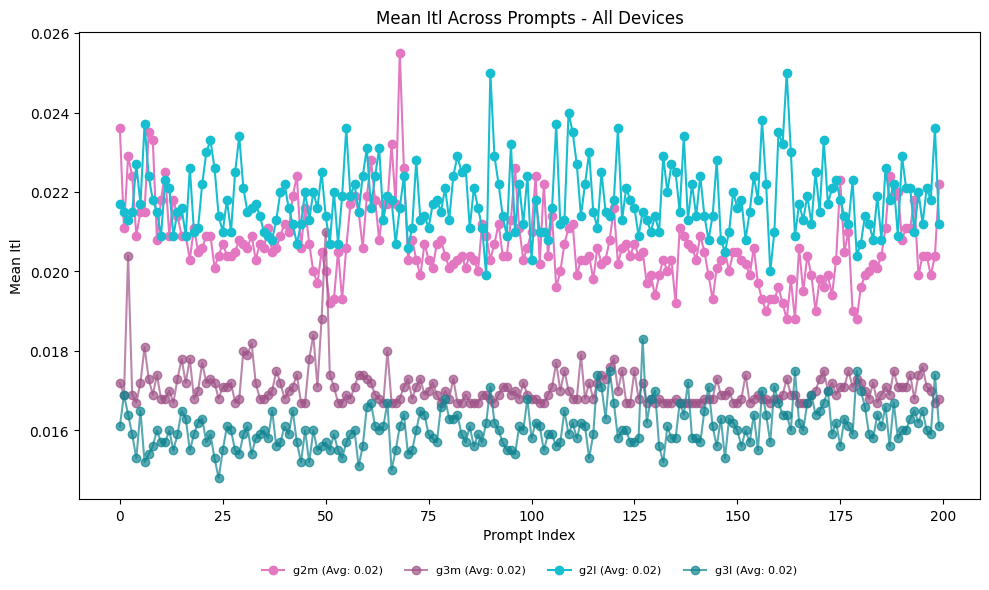

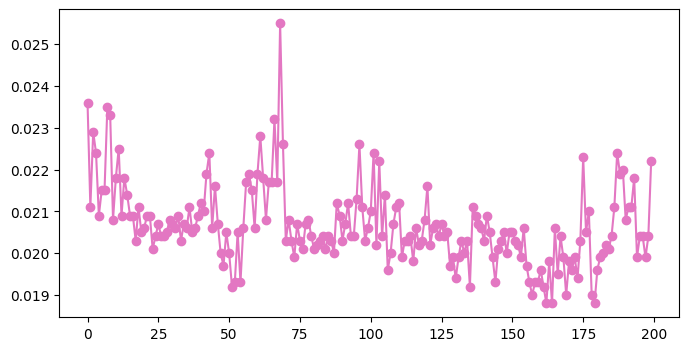

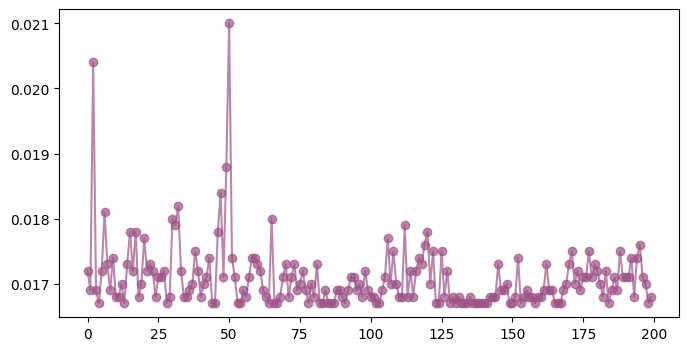

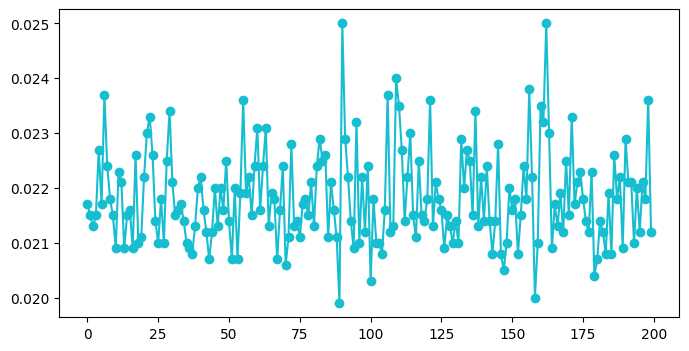

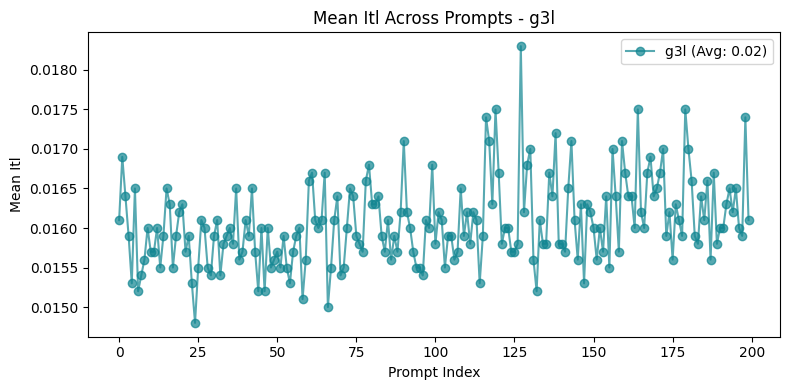

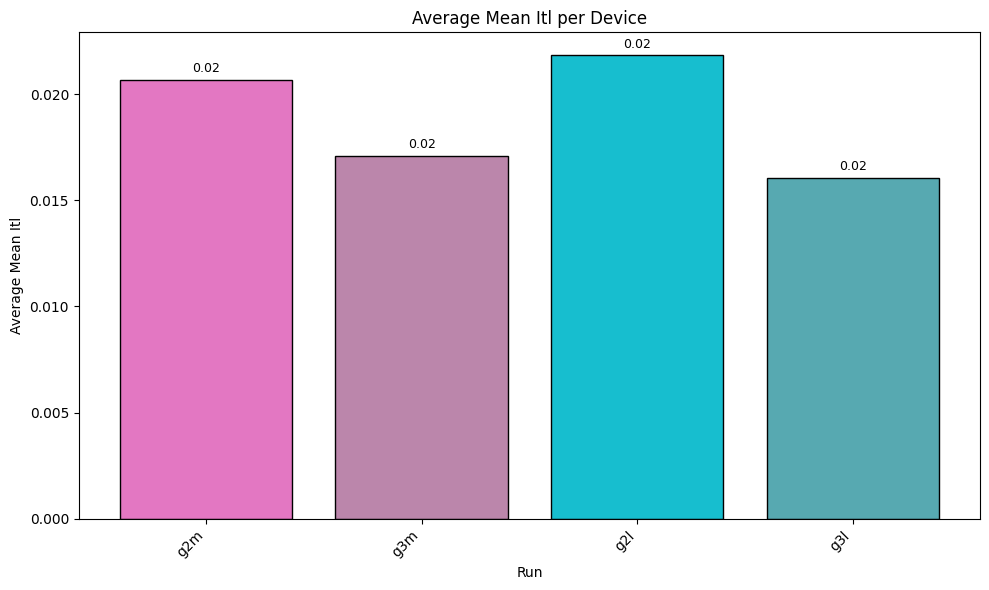

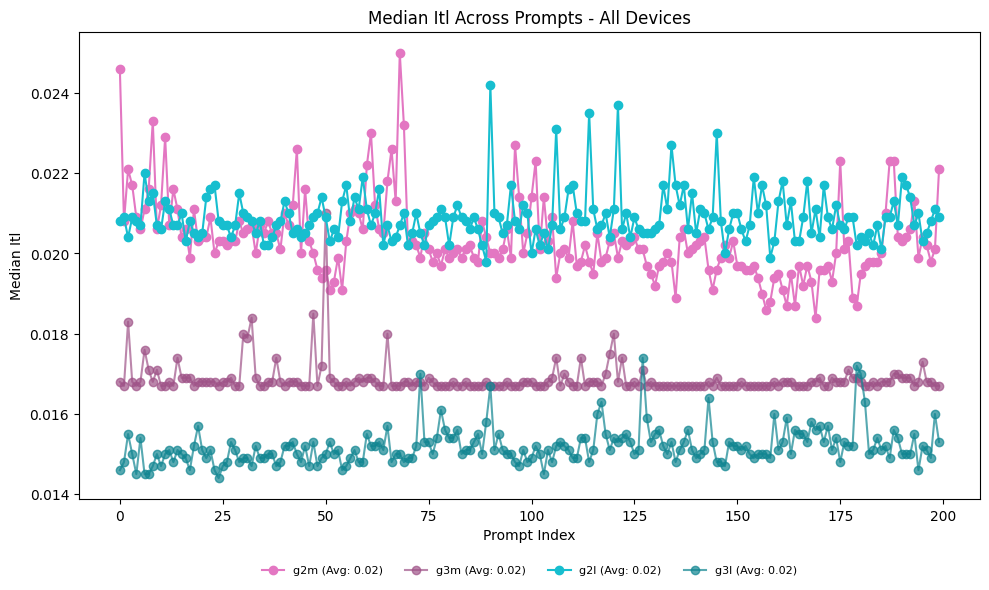

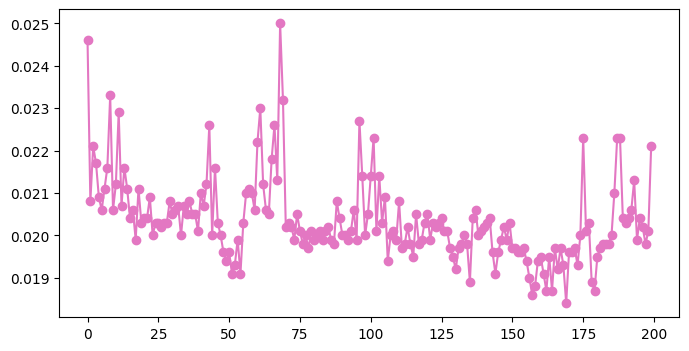

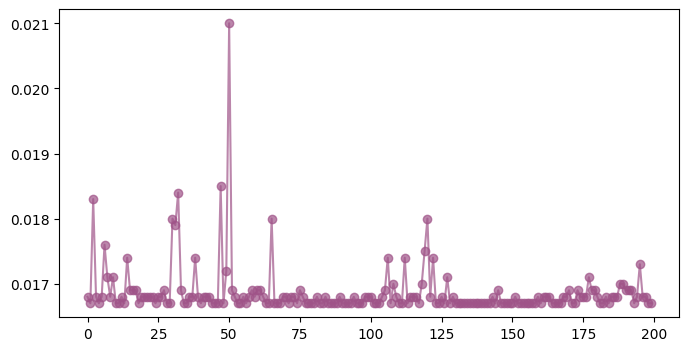

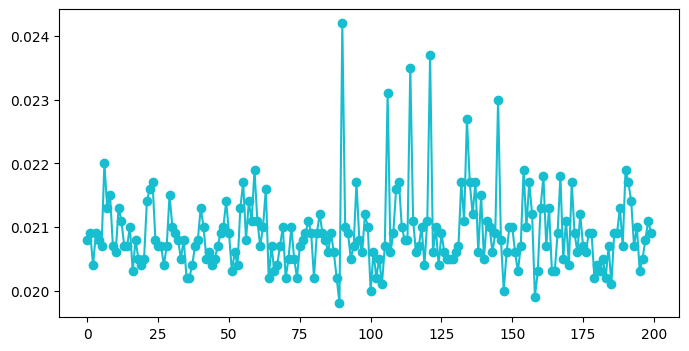

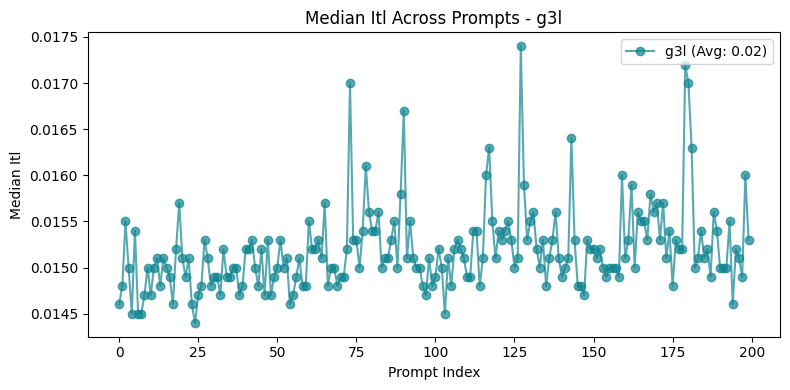

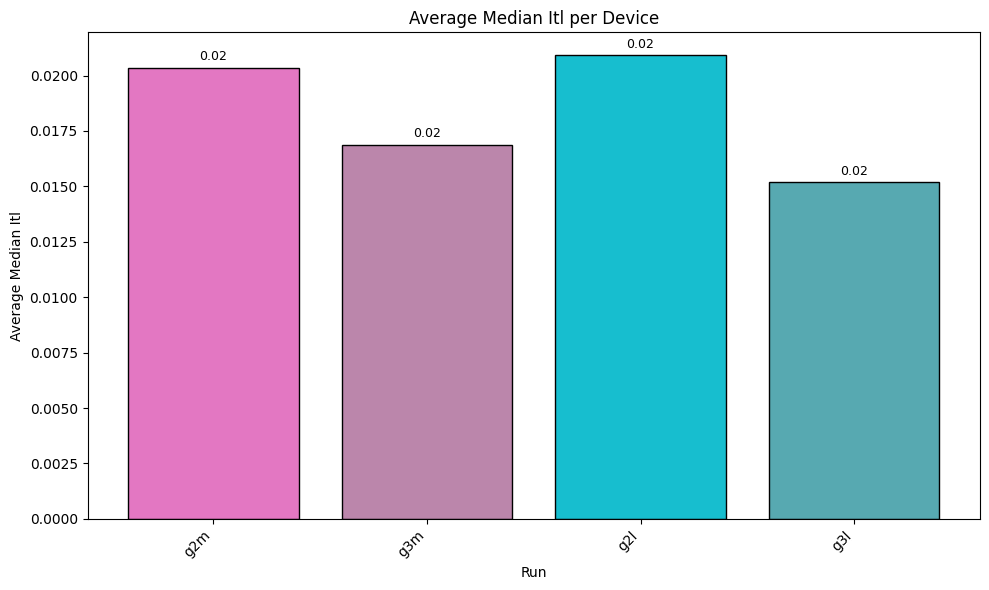

In [ ]:
# Call the function for TTFT
plot_benchmark_metric("TTFT", bench_ttft_data, bench_ttft)

# Call the function for Mean ITL
plot_benchmark_metric("Mean ITL", bench_mean_itl_data, bench_mean_itl)

# Call the function for Median ITL
plot_benchmark_metric("Median ITL", bench_median_itl_data, bench_median_itl)

In [ ]:
# Final requested code block


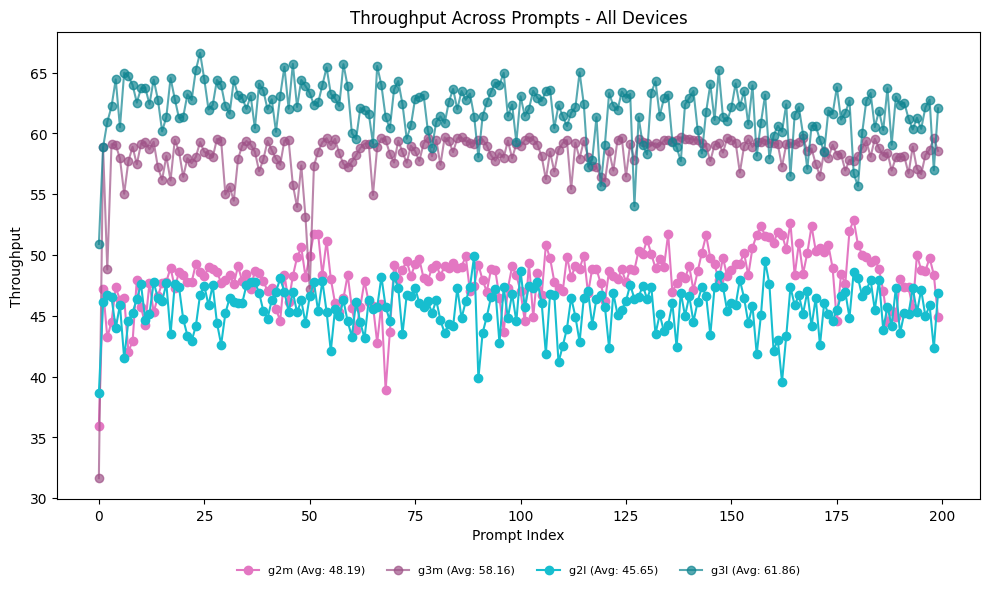

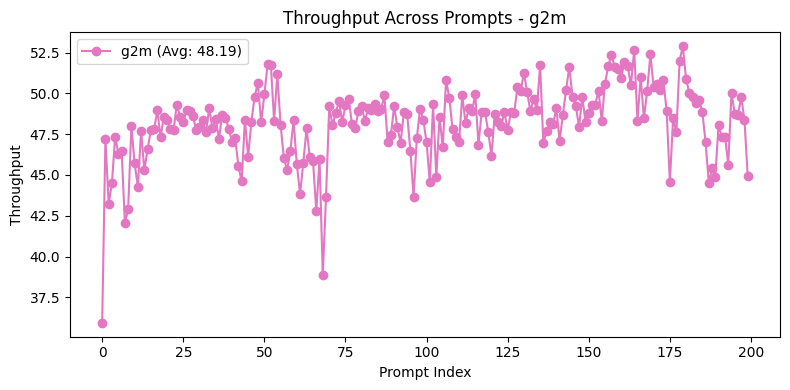

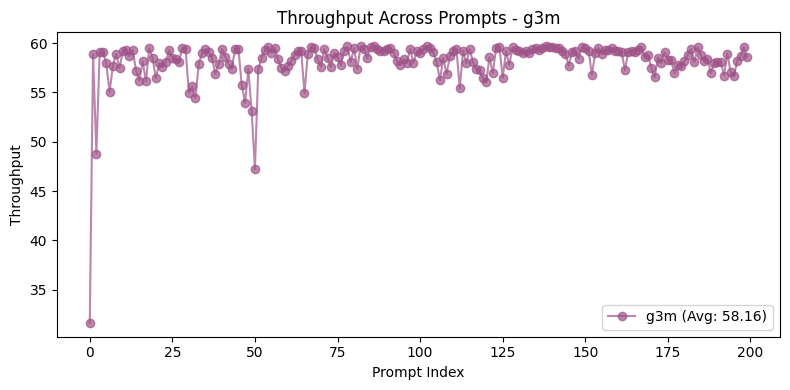

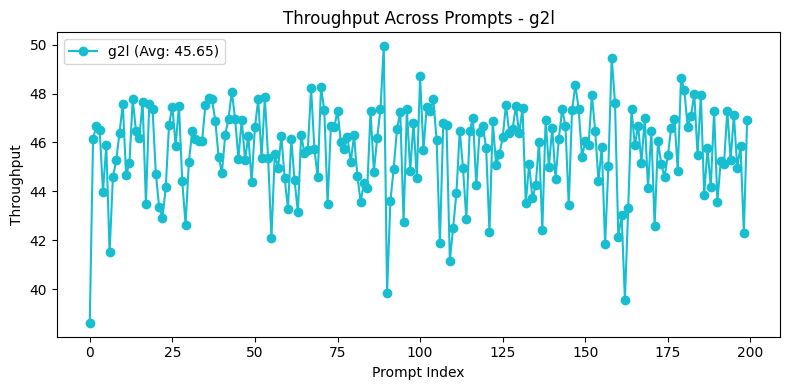

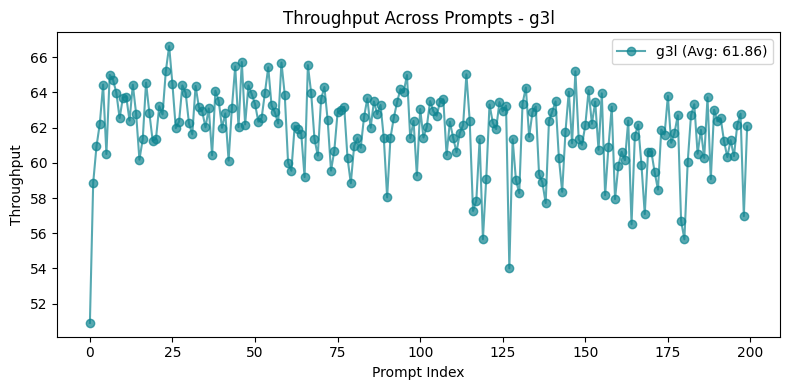

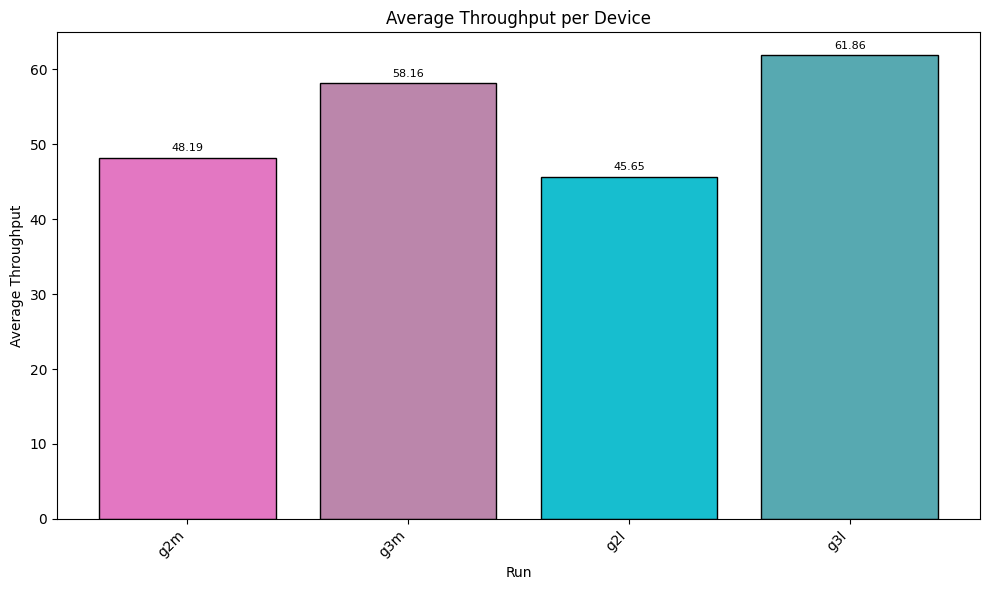

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

# ===== PLOT: ALL DEVICES THROUGHPUT =====
plt.figure(figsize=(10, 6))
for run in bench_sorted_runs:
    plt.plot(
        bench_data[run],  # Use bench_data[run] directly
        marker='o',
        label=f"{run} (Avg: {bench_throughput[run]:.2f})",
        color=bench_color_map[run],
        linestyle="-"
    )
plt.title("Throughput Across Prompts - All Devices")
plt.xlabel("Prompt Index")
plt.ylabel("Throughput")
plt.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL THROUGHPUT PLOTS =====
for run in bench_sorted_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(
        bench_data[run], # Use bench_data[run] directly
        marker='o',
        color=bench_color_map[run],
        linestyle="-",
        label=f"{run} (Avg: {bench_throughput[run]:.2f})"
    )
    plt.title(f"Throughput Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel("Throughput")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== HISTOGRAMS FOR ALL METRICS =====
# Assuming bench_data contains only throughput for now based on the error
metrics = ["throughput"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    # Use bench_throughput which already contains the average throughput
    avg_values = [bench_throughput[run] for run in bench_sorted_runs]
    plt.bar(bench_sorted_runs, avg_values, color=[bench_color_map[run] for run in bench_sorted_runs], edgecolor="black")
    for i, val in enumerate(avg_values):
        plt.text(i, val + 0.01 * max(avg_values), f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Average Throughput per Device") # Updated title
    plt.xlabel("Run")
    plt.ylabel(f"Average Throughput") # Updated ylabel
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.show()